# Appliance Energy Prediction Using Deep Learning
**Next-10-Minute Appliance Energy Forecasting with Causal Feature Engineering and Deep Recurrent Networks**

* **Author:** Dilan Dilruksha
* **Task:** One-step-ahead (10-minute) energy forecasting of household appliances (Wh).
* **Architecture:** Sliding-window feature engineering, Regularized baselines, and Deep Recurrent Networks (LSTM, GRU, CNN-LSTM).
* **Strict Temporal Discipline:** Causality preserved across all stages — no forward-looking data leakage in rolling aggregations, outlier treatment, or scaling.


## 1. Environment and Configuration

We configure the Python environment, plotting defaults, random seeds for reproducibility, and project paths.
Deep learning uses **TensorFlow / Keras**; feature engineering and evaluation use pandas, NumPy, and scikit-learn.


In [ ]:
# Core stack. Deep learning uses TensorFlow/Keras; everything else is pandas/NumPy/scikit-learn.
# If a package is missing (e.g. on a fresh runtime), uncomment:
# !pip install -q tensorflow scikit-learn pandas numpy matplotlib

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)

mpl.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "figure.dpi": 110, "font.size": 10})

# Robust dataset and output directory resolution (works from root or notebooks/)
DATA_PATH = Path("energy_data_set.csv") if Path("energy_data_set.csv").exists() else (
    Path("../data/raw/energy_data_set.csv") if Path("../data/raw/energy_data_set.csv").exists() else
    Path("data/raw/energy_data_set.csv")
)

PROCESSED_DATA_DIR = Path("../data/processed") if Path("../data").exists() else Path("data/processed")
MODELS_DIR = Path("../models") if Path("../models").exists() else Path("models")
REPORTS_DIR = Path("../reports") if Path("../reports").exists() else Path("reports")

for directory in [PROCESSED_DATA_DIR, MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TARGET = "Appliances"
FREQ = "10min"
STEPS_PER_HOUR, STEPS_PER_DAY = 6, 144
STEPS_PER_WEEK = STEPS_PER_DAY * 7

print(f"Data Path     : {DATA_PATH}")
print(f"pandas        : {pd.__version__}")
print(f"numpy         : {np.__version__}")
print(f"tensorflow    : {tf.__version__}")


## 2. Data Loading and Initial Audit

Load the raw CSV, parse the timestamp index, sort chronologically, and verify row count and observation span.


In [2]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").set_index("date")

print("shape:", df_raw.shape)
print("period:", df_raw.index.min(), "->", df_raw.index.max())
print("duration:", df_raw.index.max() - df_raw.index.min())
df_raw.head()

shape: (19735, 28)
period: 2016-01-11 17:00:00 -> 2016-05-27 18:00:00
duration: 137 days 01:00:00


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 3. Statistical Profiling

Inspect column data types, distribution quantiles, means, and extrema across all telemetry signals.


In [3]:
# dtypes and a compact statistical summary
print(df_raw.dtypes.value_counts().to_string())
df_raw.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)

float64    26
int64       2


,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.69,102.52,10.00,50.00,60.00,100.00,1080.00
lights,19735.0,3.80,7.94,0.00,0.00,0.00,0.00,70.00
T1,19735.0,21.69,1.61,16.79,20.76,21.60,22.60,26.26
RH_1,19735.0,40.26,3.98,27.02,37.33,39.66,43.07,63.36
T2,19735.0,20.34,2.19,16.10,18.79,20.00,21.50,29.86
RH_2,19735.0,40.42,4.07,20.46,37.90,40.50,43.26,56.03
T3,19735.0,22.27,2.01,17.20,20.79,22.10,23.29,29.24
RH_3,19735.0,39.24,3.25,28.77,36.90,38.53,41.76,50.16
T4,19735.0,20.86,2.04,15.10,19.53,20.67,22.10,26.20
RH_4,19735.0,39.03,4.34,27.66,35.53,38.40,42.16,51.09


## 4. Sampling Regularity and Continuity

Check for duplicated timestamps and verify that the 10-minute sampling grid is completely regular without missing intervals.


In [4]:
# Sampling regularity: are the timestamps a clean 10-minute grid with no duplicates or gaps?
step_sizes = df_raw.index.to_series().diff().value_counts()
expected_index = pd.date_range(df_raw.index.min(), df_raw.index.max(), freq=FREQ)

print("duplicated timestamps :", int(df_raw.index.duplicated().sum()))
print("distinct step sizes   :")
print(step_sizes.head().to_string())
print("timestamps missing from a complete 10-min grid:", len(expected_index.difference(df_raw.index)))

duplicated timestamps : 0
distinct step sizes   :
date
0 days 00:10:00    19734
timestamps missing from a complete 10-min grid: 0


## 5. Noise and Control Variable Audit

The source dataset includes two random variables (`rv1`, `rv2`) inserted as control attributes. We confirm their redundancy and exclude them from predictors.


In [5]:
# rv1 / rv2 are documented in the source dataset as random variables added as noise controls.
# Worth verifying rather than assuming, since two identical "random" columns would be redundant.
print("max |rv1 - rv2| :", float((df_raw["rv1"] - df_raw["rv2"]).abs().max()))
print("corr(rv1, Appliances) :", round(df_raw["rv1"].corr(df_raw[TARGET]), 4))
print("corr(rv2, Appliances) :", round(df_raw["rv2"].corr(df_raw[TARGET]), 4))

print("\nshare of rows with lights == 0 :", round((df_raw["lights"] == 0).mean(), 4))
print("Appliances: min %.0f  median %.0f  max %.0f  skew %.2f" % (
    df_raw[TARGET].min(), df_raw[TARGET].median(), df_raw[TARGET].max(), df_raw[TARGET].skew()))

max |rv1 - rv2| : 0.0
corr(rv1, Appliances) : -0.0111
corr(rv2, Appliances) : -0.0111

share of rows with lights == 0 : 0.7728
Appliances: min 10  median 60  max 1080  skew 3.39


In [6]:
df = df_raw.drop(columns=["rv1", "rv2"]).copy()
EXOG = [c for c in df.columns if c != TARGET]
print(f"{len(EXOG)} predictor columns retained:\n{EXOG}")

25 predictor columns retained:
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint']


## 6. Exploratory Data Analysis (EDA)

We explore target dynamics, time-series profiles across hours, weekdays, and months, cross-sensor correlation structures, and target autocorrelation.


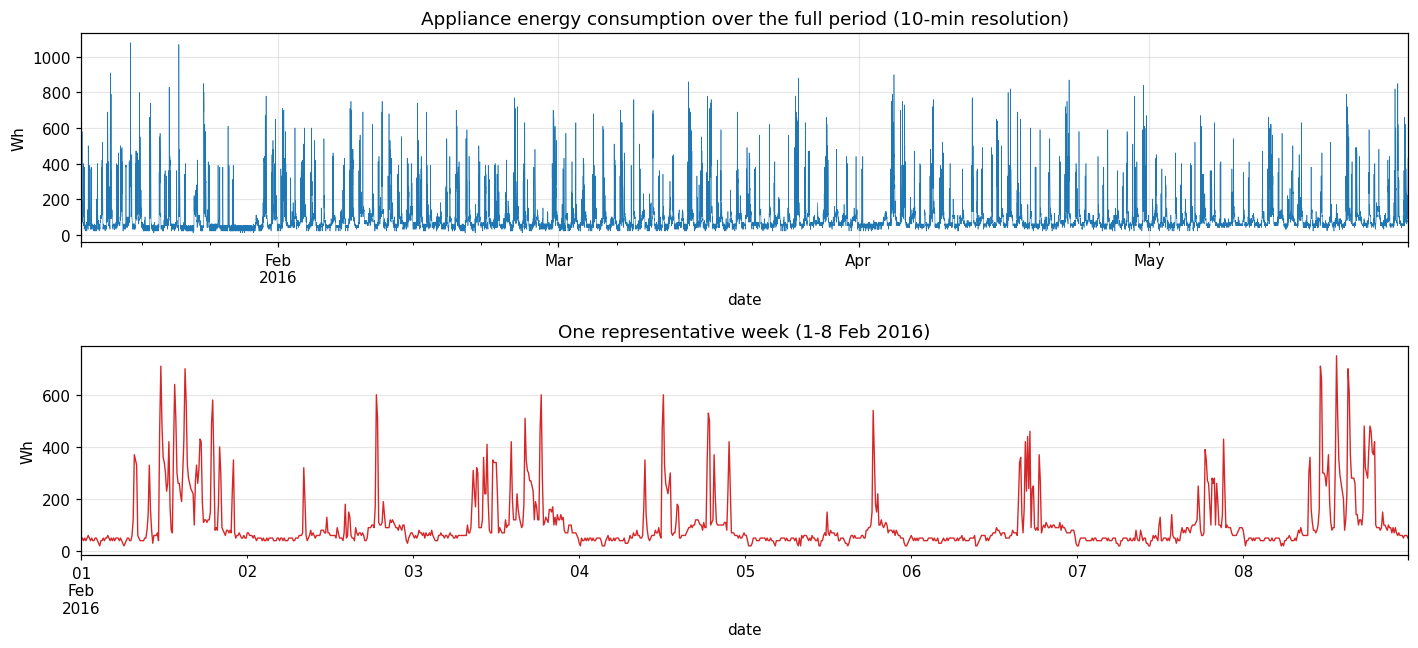

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(13, 6))

df[TARGET].plot(ax=ax[0], lw=0.4, color="tab:blue")
ax[0].set_title("Appliance energy consumption over the full period (10-min resolution)")
ax[0].set_ylabel("Wh")

week = df.loc["2016-02-01":"2016-02-08", TARGET]
week.plot(ax=ax[1], lw=0.9, color="tab:red")
ax[1].set_title("One representative week (1-8 Feb 2016)")
ax[1].set_ylabel("Wh")
plt.tight_layout(); plt.show()

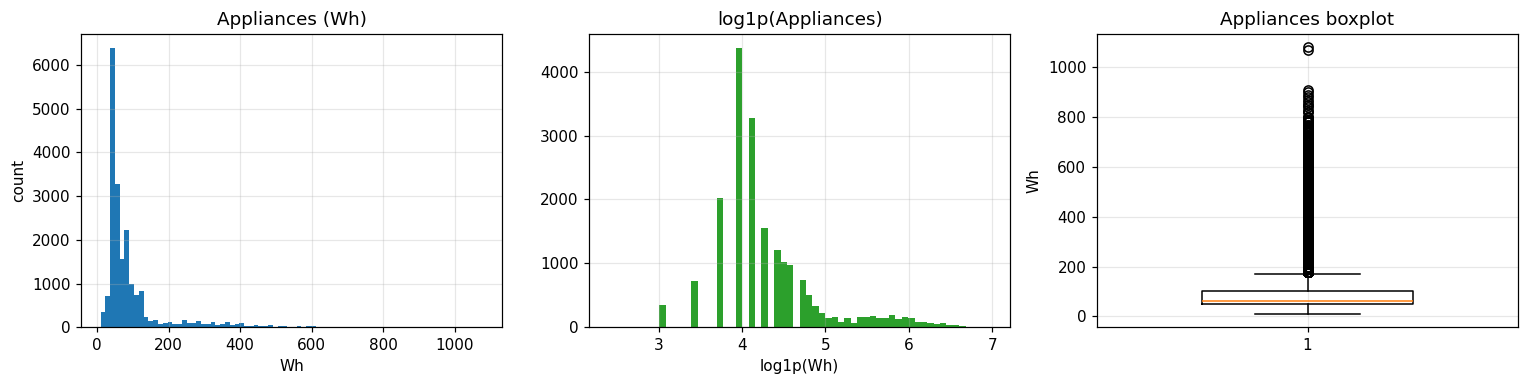

skewness raw    : 3.39
skewness log1p  : 1.19
kurtosis raw    : 13.67


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))

ax[0].hist(df[TARGET], bins=80, color="tab:blue")
ax[0].set_title("Appliances (Wh)"); ax[0].set_xlabel("Wh"); ax[0].set_ylabel("count")

ax[1].hist(np.log1p(df[TARGET]), bins=60, color="tab:green")
ax[1].set_title("log1p(Appliances)"); ax[1].set_xlabel("log1p(Wh)")

ax[2].boxplot(df[TARGET].values, widths=0.5)
ax[2].set_title("Appliances boxplot"); ax[2].set_ylabel("Wh")

plt.tight_layout(); plt.show()

print("skewness raw    : %.2f" % df[TARGET].skew())
print("skewness log1p  : %.2f" % np.log1p(df[TARGET]).skew())
print("kurtosis raw    : %.2f" % df[TARGET].kurt())

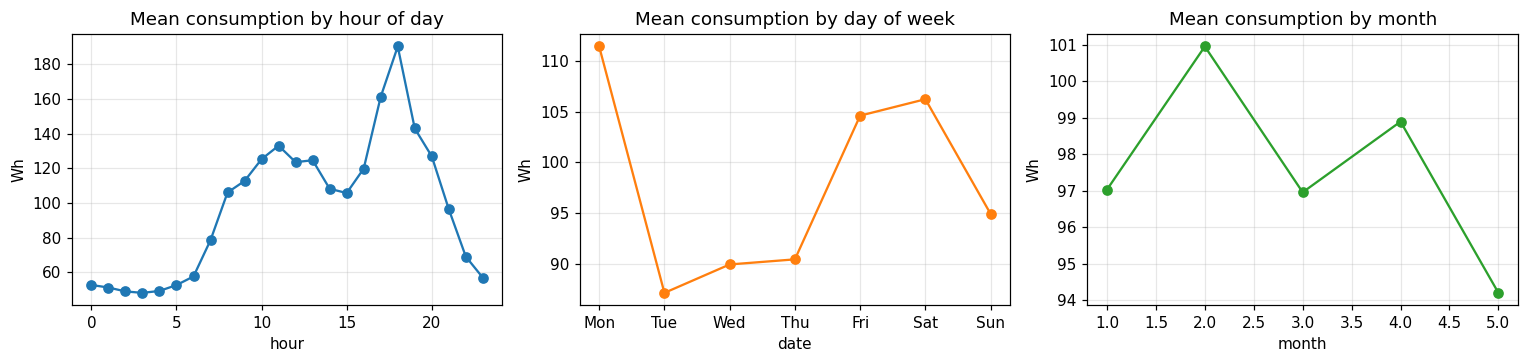

weekday vs weekend mean (Wh):
weekday     96.6
weekend    100.6


In [9]:
# Daily, weekly and monthly profiles of the target.
prof_hour = df[TARGET].groupby(df.index.hour).mean()
prof_dow = df[TARGET].groupby(df.index.dayofweek).mean()
prof_month = df[TARGET].groupby(df.index.month).mean()

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
prof_hour.plot(ax=ax[0], marker="o"); ax[0].set_title("Mean consumption by hour of day")
ax[0].set_xlabel("hour"); ax[0].set_ylabel("Wh")

prof_dow.plot(ax=ax[1], marker="o", color="tab:orange")
ax[1].set_xticks(range(7)); ax[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax[1].set_title("Mean consumption by day of week"); ax[1].set_ylabel("Wh")

prof_month.plot(ax=ax[2], marker="o", color="tab:green")
ax[2].set_title("Mean consumption by month"); ax[2].set_xlabel("month"); ax[2].set_ylabel("Wh")
plt.tight_layout(); plt.show()

print("weekday vs weekend mean (Wh):")
print(df[TARGET].groupby(np.where(df.index.dayofweek >= 5, "weekend", "weekday")).mean().round(1).to_string())

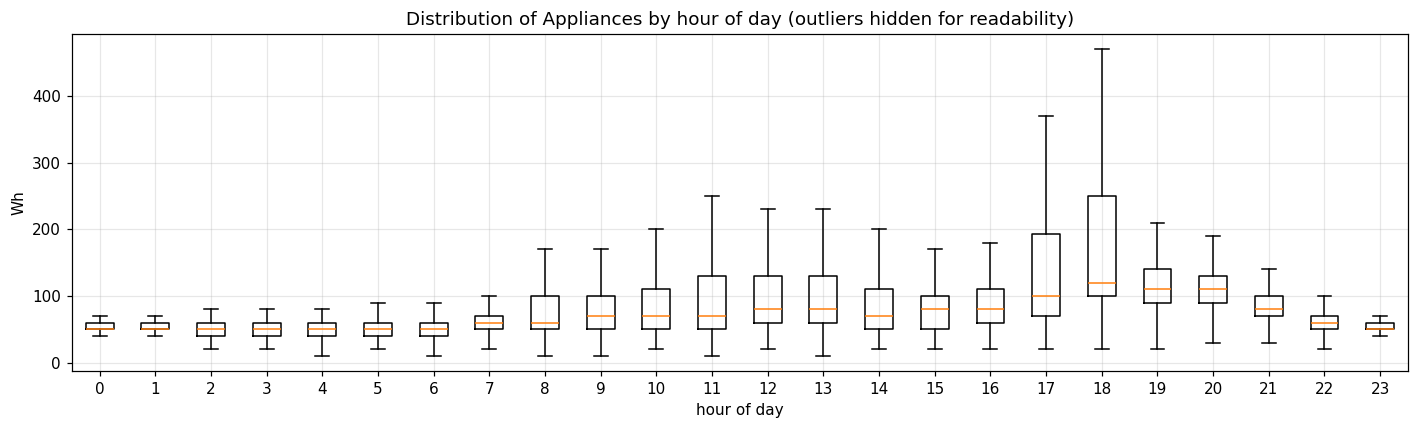

In [10]:
# Distribution (not just the mean) of consumption within each hour - spikes matter here.
hourly = [df.loc[df.index.hour == h, TARGET].values for h in range(24)]
plt.figure(figsize=(13, 4))
plt.boxplot(hourly, tick_labels=[str(h) for h in range(24)], showfliers=False)
plt.title("Distribution of Appliances by hour of day (outliers hidden for readability)")
plt.xlabel("hour of day"); plt.ylabel("Wh")
plt.tight_layout(); plt.show()

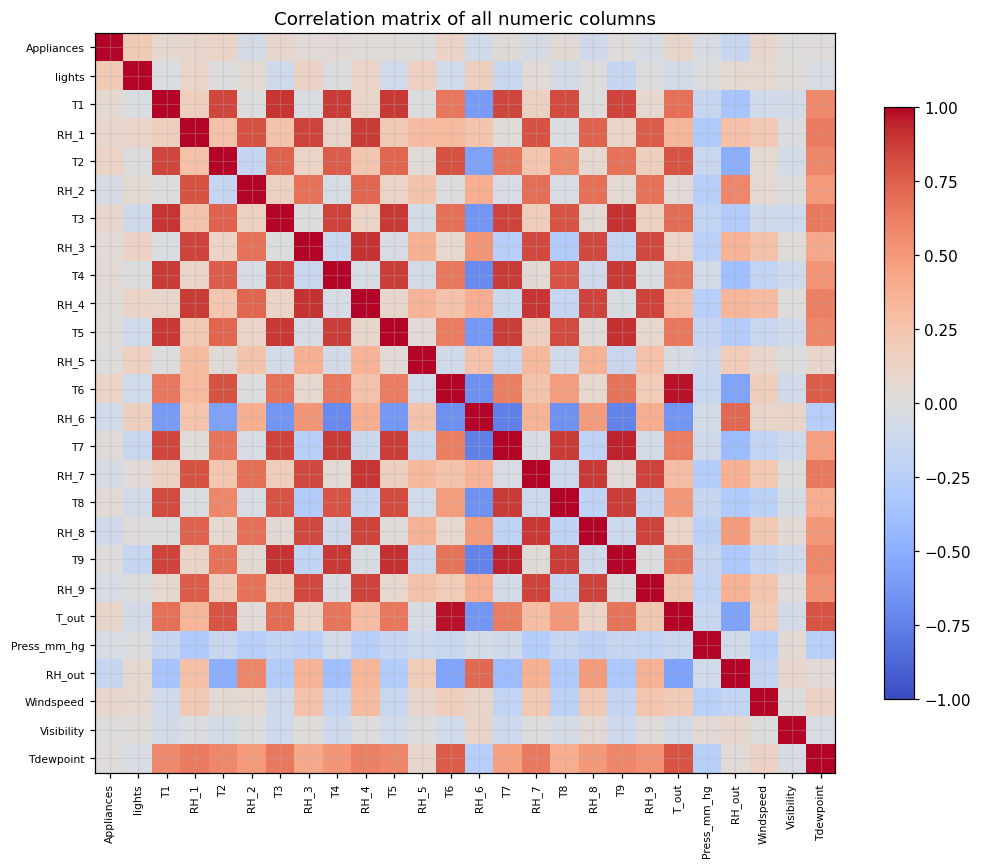

In [11]:
# Correlation structure. Plotted with imshow rather than a library heatmap so the notebook
# has one fewer dependency; cell annotation is skipped because 26x26 labels are unreadable anyway.
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
ax.set_title("Correlation matrix of all numeric columns")
fig.colorbar(im, shrink=0.8)
plt.tight_layout(); plt.show()

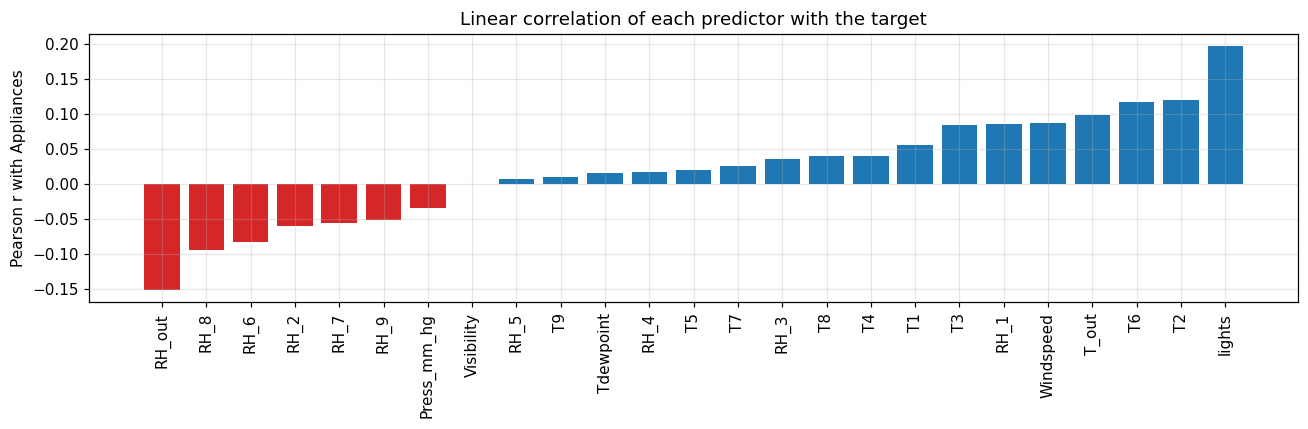

strongest absolute correlations with the target:
lights       0.197
RH_out       0.152
T2           0.120
T6           0.118
T_out        0.099
RH_8         0.094
Windspeed    0.087
RH_1         0.086


In [12]:
target_corr = corr[TARGET].drop(TARGET).sort_values()

plt.figure(figsize=(12, 4))
plt.bar(target_corr.index, target_corr.values,
        color=["tab:red" if v < 0 else "tab:blue" for v in target_corr.values])
plt.xticks(rotation=90); plt.ylabel("Pearson r with Appliances")
plt.title("Linear correlation of each predictor with the target")
plt.tight_layout(); plt.show()

print("strongest absolute correlations with the target:")
print(target_corr.abs().sort_values(ascending=False).head(8).round(3).to_string())

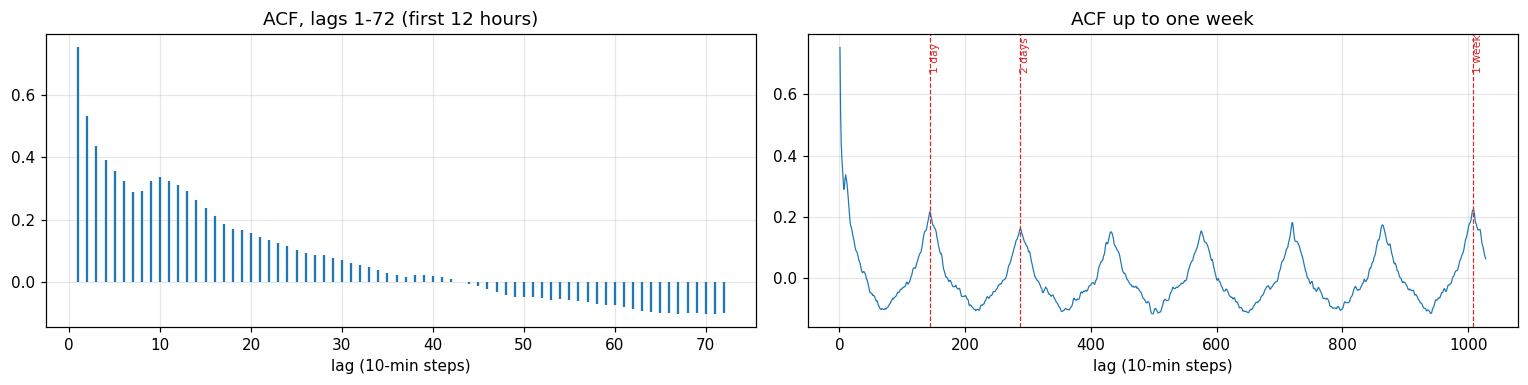

lag     1 (   10 min) : acf =  0.753
lag     2 (   20 min) : acf =  0.534
lag     3 (   30 min) : acf =  0.438
lag     6 (   60 min) : acf =  0.324
lag    12 (  120 min) : acf =  0.311
lag    18 (  180 min) : acf =  0.171
lag    36 (  360 min) : acf =  0.021
lag    72 (  720 min) : acf = -0.101
lag   144 ( 1440 min) : acf =  0.217
lag  1008 (10080 min) : acf =  0.222


In [13]:
def acf_values(series, max_lag):
    """Autocorrelation of a series for lags 1..max_lag."""
    return pd.Series({lag: series.autocorr(lag) for lag in range(1, max_lag + 1)})


acf_short = acf_values(df[TARGET], 72)                    # up to 12 hours
acf_long = acf_values(df[TARGET], STEPS_PER_WEEK + 20)    # just past one week

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].stem(acf_short.index, acf_short.values, markerfmt=" ", basefmt=" ")
ax[0].set_title("ACF, lags 1-72 (first 12 hours)"); ax[0].set_xlabel("lag (10-min steps)")

ax[1].plot(acf_long.index, acf_long.values, lw=0.8)
for k, lbl in [(STEPS_PER_DAY, "1 day"), (2 * STEPS_PER_DAY, "2 days"), (STEPS_PER_WEEK, "1 week")]:
    ax[1].axvline(k, color="tab:red", ls="--", lw=0.8)
    ax[1].text(k, ax[1].get_ylim()[1] * 0.85, lbl, rotation=90, fontsize=7, color="tab:red")
ax[1].set_title("ACF up to one week"); ax[1].set_xlabel("lag (10-min steps)")
plt.tight_layout(); plt.show()

for lag in [1, 2, 3, 6, 12, 18, 36, 72, STEPS_PER_DAY, STEPS_PER_WEEK]:
    print(f"lag {lag:5d} ({lag * 10:5d} min) : acf = {df[TARGET].autocorr(lag): .3f}")

## 7. Data Quality and Outlier Diagnostics

Assess missing cells, frozen sensor runs, and Tukey IQR outlier fences. Legitimate high-demand spikes are preserved rather than dropped.


In [14]:
na_counts = df.isna().sum()
print("total missing cells:", int(na_counts.sum()))
print(na_counts[na_counts > 0].to_string() if na_counts.sum() else "no column contains NaN")

total missing cells: 0
no column contains NaN


In [15]:
def enforce_regular_grid(frame, freq=FREQ, interp_limit=6):
    """Reindex onto a complete time grid and fill short gaps.

    Missing timestamps are inserted, then filled by time-weighted interpolation limited to
    `interp_limit` consecutive steps (1 hour at 10-min resolution). Interpolating further than
    that would invent an hour of behaviour rather than bridge a dropout, so anything longer is
    left as NaN and those rows are dropped downstream.
    """
    grid = pd.date_range(frame.index.min(), frame.index.max(), freq=freq)
    inserted = len(grid) - len(frame.index.intersection(grid))
    out = frame.reindex(grid)
    out.index.name = frame.index.name
    before = int(out.isna().sum().sum())
    out = out.interpolate(method="time", limit=interp_limit, limit_direction="both")
    after = int(out.isna().sum().sum())
    print(f"rows inserted by reindexing : {inserted}")
    print(f"NaN cells before/after interpolation : {before} -> {after}")
    return out


df = enforce_regular_grid(df)
print("shape after grid enforcement:", df.shape)

rows inserted by reindexing : 0
NaN cells before/after interpolation : 0 -> 0
shape after grid enforcement: (19735, 26)


In [16]:
def longest_constant_run(series):
    """Length of the longest run of identical consecutive values (frozen-sensor check)."""
    changed = series.ne(series.shift()).cumsum()
    return int(series.groupby(changed).transform("size").max())


runs = pd.Series({c: longest_constant_run(df[c]) for c in df.columns}).sort_values(ascending=False)
print("longest constant run per column, in 10-min steps (144 = 24h):")
print(runs.head(10).to_string())

longest constant run per column, in 10-min steps (144 = 24h):
RH_6          353
lights        352
Visibility    205
Windspeed     121
T9             79
T7             78
T5             62
RH_8           42
T2             40
T1             34


In [17]:
def iqr_bounds(series, k=1.5):
    """Lower and upper Tukey fences at k times the interquartile range."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


lo, hi = iqr_bounds(df[TARGET])
z = (df[TARGET] - df[TARGET].mean()).abs() / df[TARGET].std()
beyond = (df[TARGET] < lo) | (df[TARGET] > hi)

print(f"IQR fence for Appliances  : [{lo:.1f}, {hi:.1f}] Wh")
print(f"rows beyond the IQR fence : {int(beyond.sum())} ({beyond.mean():.2%})")
print(f"rows with |z| > 3         : {int((z > 3).sum())} ({(z > 3).mean():.2%})")
print(f"rows below the lower fence: {int((df[TARGET] < lo).sum())}")

IQR fence for Appliances  : [-25.0, 175.0] Wh
rows beyond the IQR fence : 2138 (10.83%)
rows with |z| > 3         : 540 (2.74%)
rows below the lower fence: 0


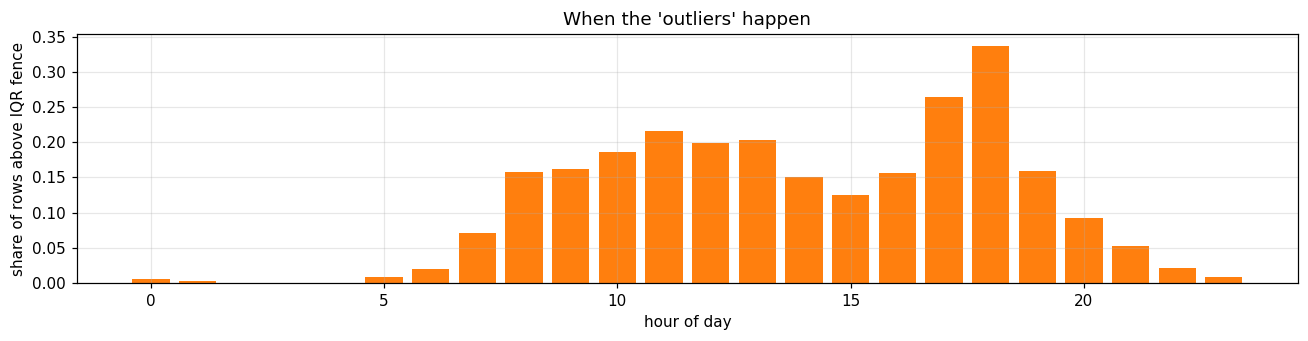

In [18]:
# Where do the flagged rows sit in time? If they cluster in the evening they are behaviour,
# not measurement error.
flagged = df[TARGET] > hi
plt.figure(figsize=(12, 3.2))
plt.bar(range(24), flagged.groupby(df.index.hour).mean().values, color="tab:orange")
plt.xlabel("hour of day"); plt.ylabel("share of rows above IQR fence")
plt.title("When the 'outliers' happen")
plt.tight_layout(); plt.show()

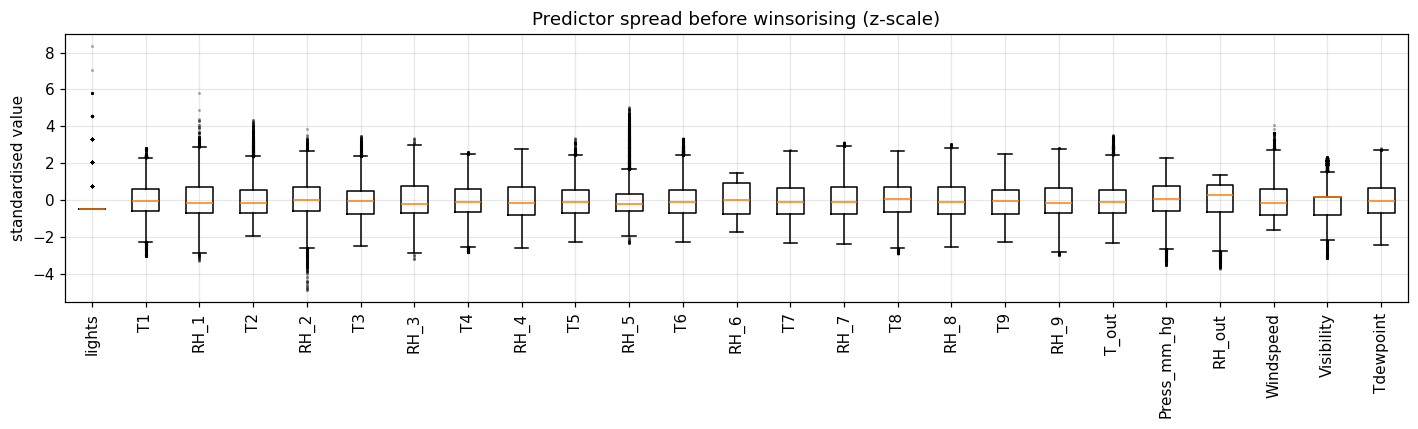

In [19]:
# Spread of the predictor columns before any treatment, standardised so they fit on one axis.
preview = (df[EXOG] - df[EXOG].mean()) / df[EXOG].std()
plt.figure(figsize=(13, 4))
plt.boxplot([preview[c].dropna().values for c in EXOG], tick_labels=EXOG,
            flierprops=dict(marker=".", markersize=2, alpha=0.3))
plt.xticks(rotation=90); plt.ylabel("standardised value")
plt.title("Predictor spread before winsorising (z-scale)")
plt.tight_layout(); plt.show()

## 8. Leakage-Safe Feature Engineering

Construct causal lag features, rolling window aggregates, momentum/differences, calendar cyclics, holiday flags, and environmental interaction terms.
All features use information strictly prior to target timestamp $t$.


In [20]:
def build_features(frame, target=TARGET):
    """Build the leakage-safe design matrix.

    All sensor, lag, rolling and difference features are computed from values strictly before the
    timestamp of the row they belong to. Calendar features use the timestamp itself, which is
    known ahead of time. Returns (X, y) aligned on the same index, with warm-up rows dropped.
    """
    X = pd.DataFrame(index=frame.index)
    past = frame[target].shift(1)          # target history, never the current value
    exog = [c for c in frame.columns if c != target]

    # --- 1. exogenous sensors, lagged one step ------------------------------------------
    for col in exog:
        X[f"{col}_lag1"] = frame[col].shift(1)

    # --- 2. lagged target ---------------------------------------------------------------
    for lag in [1, 2, 3, 4, 5, 6, 12, 18, 36, STEPS_PER_DAY, STEPS_PER_WEEK]:
        X[f"app_lag{lag}"] = frame[target].shift(lag)

    # --- 3. rolling window statistics over past values ----------------------------------
    for win, name in [(6, "1h"), (18, "3h"), (36, "6h"), (144, "24h")]:
        roll = past.rolling(win)
        X[f"app_mean_{name}"] = roll.mean()
        X[f"app_std_{name}"] = roll.std()
        X[f"app_max_{name}"] = roll.max()
        X[f"app_min_{name}"] = roll.min()
    X["lights_mean_1h"] = frame["lights"].shift(1).rolling(6).mean()
    X["T_out_mean_3h"] = frame["T_out"].shift(1).rolling(18).mean()

    # --- 4. differences / momentum ------------------------------------------------------
    X["app_diff_1"] = frame[target].shift(1) - frame[target].shift(2)
    X["app_diff_6"] = frame[target].shift(1) - frame[target].shift(7)
    X["app_dev_from_24h"] = frame[target].shift(1) - X["app_mean_24h"]

    # --- 5. calendar ---------------------------------------------------------------------
    idx = frame.index
    nsm = idx.hour * 3600 + idx.minute * 60        # equivalent of the brief's NSM column
    X["hour"] = idx.hour
    X["day_of_week"] = idx.dayofweek
    X["month"] = idx.month
    X["is_weekend"] = (idx.dayofweek >= 5).astype(int)
    X["nsm"] = nsm
    X["hour_sin"] = np.sin(2 * np.pi * nsm / 86400)
    X["hour_cos"] = np.cos(2 * np.pi * nsm / 86400)
    X["dow_sin"] = np.sin(2 * np.pi * idx.dayofweek / 7)
    X["dow_cos"] = np.cos(2 * np.pi * idx.dayofweek / 7)

    # --- 6. domain: Belgian public holidays inside the observed window --------------------
    holidays = pd.to_datetime(["2016-01-01", "2016-03-27", "2016-03-28",
                               "2016-05-01", "2016-05-05", "2016-05-15", "2016-05-16"])
    X["is_holiday"] = np.isin(idx.normalize(), holidays).astype(int)
    X["is_non_working"] = ((X["is_weekend"] == 1) | (X["is_holiday"] == 1)).astype(int)

    # --- 7. interaction terms --------------------------------------------------------------
    t_cols = ["T1", "T2", "T3", "T4", "T5", "T7", "T8", "T9"]
    rh_cols = ["RH_1", "RH_2", "RH_3", "RH_4", "RH_5", "RH_7", "RH_8", "RH_9"]
    X["T_indoor_mean"] = frame[t_cols].shift(1).mean(axis=1)
    X["RH_indoor_mean"] = frame[rh_cols].shift(1).mean(axis=1)
    X["T_x_RH_indoor"] = X["T_indoor_mean"] * X["RH_indoor_mean"]
    X["T_out_x_RH_out"] = frame["T_out"].shift(1) * frame["RH_out"].shift(1)
    X["indoor_minus_outdoor_T"] = X["T_indoor_mean"] - frame["T_out"].shift(1)
    X["dewpoint_spread"] = frame["T_out"].shift(1) - frame["Tdewpoint"].shift(1)
    X["T_indoor_range"] = frame[t_cols].shift(1).max(axis=1) - frame[t_cols].shift(1).min(axis=1)
    X["evening_peak_flag"] = ((idx.hour >= 17) & (idx.hour <= 20)).astype(int)
    X["hour_x_weekend"] = X["hour_sin"] * X["is_weekend"]

    combined = X.join(frame[target].rename("__y__")).dropna()   # drops the 1-week warm-up
    return combined.drop(columns="__y__"), combined["__y__"].rename(target)


X_all, y_all = build_features(df)
print("design matrix:", X_all.shape)
print("usable period:", X_all.index.min(), "->", X_all.index.max())
print("rows lost to feature warm-up:", len(df) - len(X_all))

design matrix: (18727, 77)
usable period: 2016-01-18 17:00:00 -> 2016-05-27 18:00:00
rows lost to feature warm-up: 1008


In [21]:
# Quick look at the engineered block, grouped by family, to confirm nothing is degenerate.
groups = {
    "exogenous (lag1)": [c for c in X_all.columns if c.endswith("_lag1")],
    "target lags": [c for c in X_all.columns if c.startswith("app_lag")],
    "rolling": [c for c in X_all.columns
                if any(c.startswith(p) for p in ("app_mean", "app_std", "app_max", "app_min"))
                or c in ("lights_mean_1h", "T_out_mean_3h")],
    "difference": [c for c in X_all.columns if "diff" in c or "dev_from" in c],
    "calendar/domain": ["hour", "day_of_week", "month", "is_weekend", "nsm", "hour_sin",
                        "hour_cos", "dow_sin", "dow_cos", "is_holiday", "is_non_working",
                        "evening_peak_flag"],
}
groups["interaction"] = [c for c in X_all.columns if c not in sum(groups.values(), [])]
for name, cols in groups.items():
    print(f"{name:20s} {len(cols):3d} features")
print("\nconstant columns:", [c for c in X_all.columns if X_all[c].nunique() == 1])
X_all.iloc[:3, :6]

exogenous (lag1)      26 features
target lags           11 features
rolling               18 features
difference             3 features
calendar/domain       12 features
interaction            8 features

constant columns: []


,lights_lag1,T1_lag1,RH_1_lag1,T2_lag1,RH_2_lag1,T3_lag1
date,,,,,,
2016-01-18 17:00:00,0.0,19.29,41.29,18.100000,41.56,19.566667
2016-01-18 17:10:00,0.0,19.20,41.20,18.066667,41.56,19.500000
2016-01-18 17:20:00,0.0,19.20,41.20,18.000000,41.50,19.500000


## 9. Chronological Split, Winsorisation, and Feature Selection

Split data in strict temporal order (72% train, 8% validation, 20% test). Derive winsorization fences and standardisation scalers strictly from training data.
Select the top consensus features using Random Forest importance, Ridge RFE, and correlation ranking.


train  13482 rows (72.0%)  2016-01-18 17:00:00 -> 2016-04-21 07:50:00
val     1499 rows ( 8.0%)  2016-04-21 08:00:00 -> 2016-05-01 17:40:00
test    3746 rows (20.0%)  2016-05-01 17:50:00 -> 2016-05-27 18:00:00


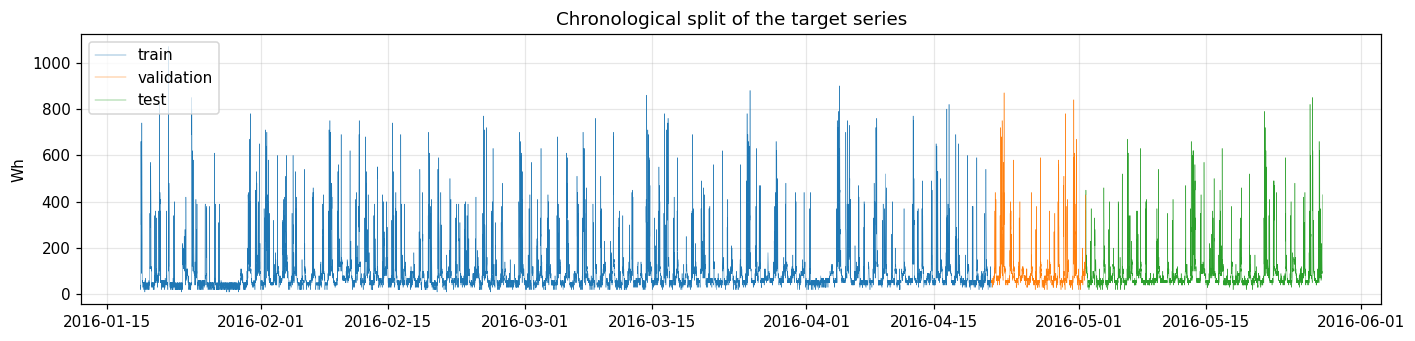

In [22]:
n = len(X_all)
i_test = int(n * 0.80)
i_val = int(i_test * 0.90)

X_train, y_train = X_all.iloc[:i_val], y_all.iloc[:i_val]
X_val, y_val = X_all.iloc[i_val:i_test], y_all.iloc[i_val:i_test]
X_test, y_test = X_all.iloc[i_test:], y_all.iloc[i_test:]

for name, Xs in [("train", X_train), ("val", X_val), ("test", X_test)]:
    print(f"{name:5s} {len(Xs):6d} rows ({len(Xs) / n:5.1%})  {Xs.index.min()} -> {Xs.index.max()}")

plt.figure(figsize=(13, 3.2))
plt.plot(y_train.index, y_train, lw=0.3, label="train")
plt.plot(y_val.index, y_val, lw=0.3, label="validation")
plt.plot(y_test.index, y_test, lw=0.3, label="test")
plt.legend(loc="upper left"); plt.ylabel("Wh")
plt.title("Chronological split of the target series")
plt.tight_layout(); plt.show()

In [23]:
# Winsorise predictors using fences derived from the TRAINING rows only (see section 5).
NO_CLIP = {"hour", "day_of_week", "month", "is_weekend", "nsm", "hour_sin", "hour_cos",
           "dow_sin", "dow_cos", "is_holiday", "is_non_working", "evening_peak_flag",
           "hour_x_weekend"}
clip_cols = [c for c in X_all.columns if c not in NO_CLIP]

bounds = {c: iqr_bounds(X_train[c], k=3.0) for c in clip_cols}   # k=3 -> only extreme values


def winsorise(frame):
    """Clip every non-categorical column to the training-set fences."""
    out = frame.copy()
    for c, (low, high) in bounds.items():
        out[c] = out[c].clip(low, high)
    return out


capped = np.mean([((X_train[c] < bounds[c][0]) | (X_train[c] > bounds[c][1])).mean()
                  for c in clip_cols])
print(f"mean share of training values capped per column: {capped:.2%}")

X_train_w, X_val_w, X_test_w = winsorise(X_train), winsorise(X_val), winsorise(X_test)

mean share of training values capped per column: 2.50%


In [24]:
x_scaler = StandardScaler().fit(X_train_w)
Xtr_s = x_scaler.transform(X_train_w)
Xva_s = x_scaler.transform(X_val_w)
Xte_s = x_scaler.transform(X_test_w)

y_scaler = StandardScaler().fit(np.log1p(y_train.values).reshape(-1, 1))


def y_forward(values):
    """Wh -> log1p -> standardised (model space)."""
    return y_scaler.transform(np.log1p(np.asarray(values, float)).reshape(-1, 1)).ravel()


def y_inverse(values):
    """Model space -> Wh."""
    return np.expm1(y_scaler.inverse_transform(np.asarray(values, float).reshape(-1, 1)).ravel())


ytr_s, yva_s, yte_s = y_forward(y_train), y_forward(y_val), y_forward(y_test)

# sanity check: the inverse transform must round-trip
assert np.allclose(y_inverse(ytr_s), y_train.values, atol=1e-6)
print("train feature matrix:", Xtr_s.shape,
      "| target mean/std after transform:", round(ytr_s.mean(), 3), round(ytr_s.std(), 3))

train feature matrix: (13482, 77) | target mean/std after transform: 0.0 1.0


In [25]:
rf_selector = RandomForestRegressor(n_estimators=200, max_depth=18, min_samples_leaf=3,
                                    n_jobs=-1, random_state=RANDOM_STATE)
rf_selector.fit(Xtr_s, ytr_s)
rf_imp = pd.Series(rf_selector.feature_importances_, index=X_all.columns).sort_values(ascending=False)

rfe = RFE(Ridge(alpha=1.0), n_features_to_select=30, step=5).fit(Xtr_s, ytr_s)
rfe_keep = set(X_all.columns[rfe.support_])

corr_rank = X_train.corrwith(y_train).abs().sort_values(ascending=False)

votes = pd.Series(0, index=X_all.columns)
votes[rf_imp.head(30).index] += 1
votes[list(rfe_keep)] += 1
votes[corr_rank.head(30).index] += 1

SELECTED = sorted(votes[votes >= 2].index.tolist())
print(f"{len(SELECTED)} features selected by majority vote:\n")
for c in SELECTED:
    print(f"  {c:26s} rf_imp={rf_imp[c]:.4f}  |r|={corr_rank.get(c, np.nan):.3f}  "
          f"rfe={'Y' if c in rfe_keep else 'n'}")

28 features selected by majority vote:

  T8_lag1                    rf_imp=0.0047  |r|=0.084  rfe=Y
  app_dev_from_24h           rf_imp=0.0117  |r|=0.719  rfe=n
  app_diff_1                 rf_imp=0.0141  |r|=0.305  rfe=Y
  app_diff_6                 rf_imp=0.0046  |r|=0.395  rfe=Y
  app_lag1                   rf_imp=0.7262  |r|=0.756  rfe=Y
  app_lag1008                rf_imp=0.0038  |r|=0.219  rfe=n
  app_lag144                 rf_imp=0.0041  |r|=0.221  rfe=n
  app_lag2                   rf_imp=0.0076  |r|=0.543  rfe=n
  app_lag3                   rf_imp=0.0076  |r|=0.442  rfe=n
  app_lag4                   rf_imp=0.0047  |r|=0.398  rfe=n
  app_max_1h                 rf_imp=0.0056  |r|=0.616  rfe=Y
  app_max_3h                 rf_imp=0.0089  |r|=0.540  rfe=Y
  app_max_6h                 rf_imp=0.0028  |r|=0.408  rfe=Y
  app_mean_1h                rf_imp=0.0059  |r|=0.595  rfe=n
  app_mean_3h                rf_imp=0.0080  |r|=0.521  rfe=Y
  app_mean_6h                rf_imp=0.0048  |

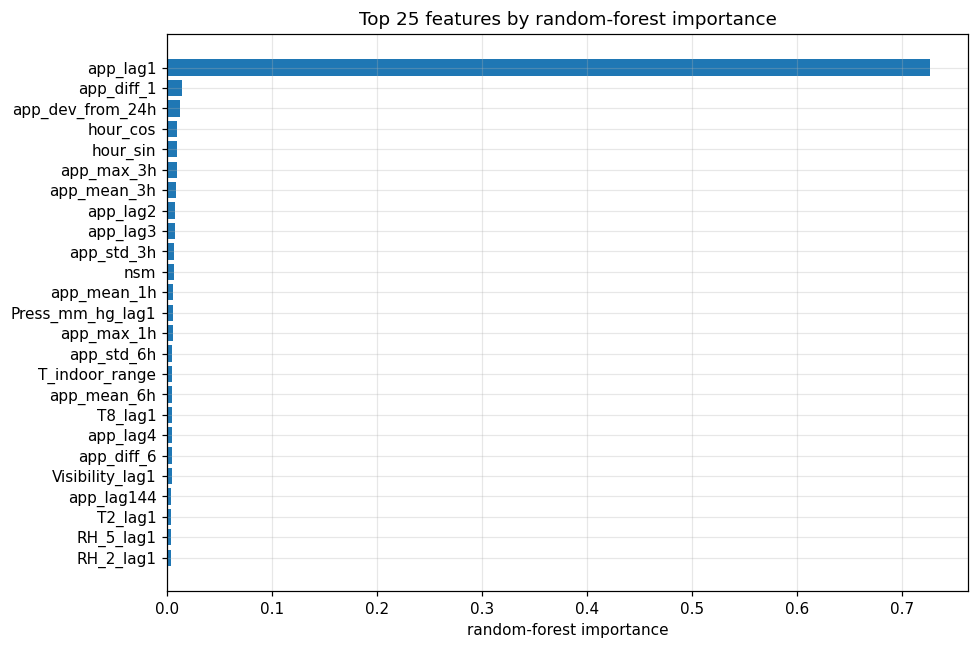

In [26]:
plt.figure(figsize=(9, 6))
top = rf_imp.head(25)[::-1]
plt.barh(top.index, top.values, color="tab:blue")
plt.xlabel("random-forest importance")
plt.title("Top 25 features by random-forest importance")
plt.tight_layout(); plt.show()

In [27]:
# Index positions of the selected features, so the same subset can be sliced out of the
# already-scaled arrays without rebuilding them.
sel_idx = [X_all.columns.get_loc(c) for c in SELECTED]
Xtr_sel, Xva_sel, Xte_sel = Xtr_s[:, sel_idx], Xva_s[:, sel_idx], Xte_s[:, sel_idx]
print("selected-feature matrices:", Xtr_sel.shape, Xva_sel.shape, Xte_sel.shape)

selected-feature matrices: (13482, 28) (1499, 28) (3746, 28)


## 10. Exporting Preprocessed Datasets and Metadata

Persist the fitted preprocessor pipeline and export the preprocessed training, validation, and test datasets to `data/processed/`.


In [ ]:
# Save fitted preprocessor payload
preprocessor_payload = {
    "x_scaler": x_scaler,
    "y_scaler": y_scaler,
    "selected_features": SELECTED,
    "all_features": list(X_all.columns),
    "bounds": bounds,
    "lookback": LOOKBACK if "LOOKBACK" in locals() else 36,
    "target": TARGET,
    "freq": FREQ,
}
joblib.dump(preprocessor_payload, MODELS_DIR / "preprocessor.joblib")

# Export preprocessed feature sets to data/processed/
train_export = pd.DataFrame(Xtr_sel, index=X_train.index, columns=SELECTED)
train_export["target_Wh"] = y_train.values
train_export["target_scaled"] = ytr_s
train_export.to_csv(PROCESSED_DATA_DIR / "train_processed.csv")

val_export = pd.DataFrame(Xva_sel, index=X_val.index, columns=SELECTED)
val_export["target_Wh"] = y_val.values
val_export["target_scaled"] = yva_s
val_export.to_csv(PROCESSED_DATA_DIR / "val_processed.csv")

test_export = pd.DataFrame(Xte_sel, index=X_test.index, columns=SELECTED)
test_export["target_Wh"] = y_test.values
test_export["target_scaled"] = yte_s
test_export.to_csv(PROCESSED_DATA_DIR / "test_processed.csv")

with open(REPORTS_DIR / "selected_features.json", "w") as f:
    json.dump({"selected_features": SELECTED, "count": len(SELECTED)}, f, indent=2)

print(f"✓ Preprocessor saved to       : {MODELS_DIR / 'preprocessor.joblib'}")
print(f"✓ Processed data saved to     : {PROCESSED_DATA_DIR}")
print(f"✓ Selected features saved to  : {REPORTS_DIR / 'selected_features.json'}")


## 11. Baseline Models (Persistence, Ridge, Random Forest)

Establish performance baselines: simple persistence ($y_t = y_{t-1}$), regularized Ridge regression, and non-linear Random Forest regression.


In [45]:
LOOKBACK = 36        # 6 hours of 10-minute steps


def make_sequences(features, targets, lookback=LOOKBACK):
    """Turn a 2-D feature matrix into 3-D windows.

    Returns X of shape (n_windows, lookback, n_features) and y of shape (n_windows,), where
    X[i] spans rows i .. i+lookback-1 and y[i] is the target at row i+lookback - so each window
    ends strictly before the value it predicts.
    """
    windows = np.lib.stride_tricks.sliding_window_view(
        features, (lookback, features.shape[1])).squeeze(1)[:-1]
    return np.ascontiguousarray(windows), np.asarray(targets)[lookback:]


# Build sequences over the whole timeline once, then slice by target position.
X_full_sel = np.vstack([Xtr_sel, Xva_sel, Xte_sel])
y_full_s = np.concatenate([ytr_s, yva_s, yte_s])

X_seq, y_seq = make_sequences(X_full_sel, y_full_s)
seq_target_pos = np.arange(LOOKBACK, len(y_full_s))      # row index each window predicts

train_mask = seq_target_pos < i_val
val_mask = (seq_target_pos >= i_val) & (seq_target_pos < i_test)
test_mask = seq_target_pos >= i_test

Xtr_seq, ytr_seq = X_seq[train_mask], y_seq[train_mask]
Xva_seq, yva_seq = X_seq[val_mask], y_seq[val_mask]
Xte_seq, yte_seq = X_seq[test_mask], y_seq[test_mask]

y_test_seq_wh = y_inverse(yte_seq)                       # actual test values, in Wh
test_index = X_all.index[seq_target_pos[test_mask]]      # timestamps, for plotting

print("train", Xtr_seq.shape, "| val", Xva_seq.shape, "| test", Xte_seq.shape)
assert len(y_test_seq_wh) == int(test_mask.sum()) == len(test_index)
# the deep models are scored on exactly the same test rows as the baselines:
print("deep test rows:", int(test_mask.sum()), "| baseline test rows:", len(y_test))

train (13446, 36, 28) | val (1499, 36, 28) | test (3746, 36, 28)
deep test rows: 3746 | baseline test rows: 3746


In [46]:
INPUT_SHAPE = (LOOKBACK, Xtr_seq.shape[2])


def build_lstm(units=64, dropout=0.2, lr=1e-3):
    """Two stacked LSTM layers with dropout and a small dense head."""
    model = keras.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.LSTM(units, return_sequences=True, dropout=dropout),
        layers.LSTM(max(units // 2, 8), dropout=dropout),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1),
    ], name="LSTM")
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse", metrics=["mae"])
    return model


def build_gru(units=64, dropout=0.2, lr=1e-3):
    """GRU counterpart of the LSTM, same depth and head."""
    model = keras.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.GRU(units, return_sequences=True, dropout=dropout),
        layers.GRU(max(units // 2, 8), dropout=dropout),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1),
    ], name="GRU")
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse", metrics=["mae"])
    return model


def build_cnn_lstm(units=64, dropout=0.2, lr=1e-3, filters=None):
    """1-D convolutional front end (local shape) followed by an LSTM (longer dependency)."""
    filters = filters or units
    model = keras.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv1D(filters, kernel_size=3, padding="causal", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.LSTM(units, dropout=dropout),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1),
    ], name="CNN_LSTM")
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse", metrics=["mae"])
    return model


build_lstm().summary()
# Save baseline model artifacts
joblib.dump(ridge, MODELS_DIR / "ridge_model.joblib")
joblib.dump(rf, MODELS_DIR / "random_forest_model.joblib", compress=3)
print(f"✓ Baseline models saved to {MODELS_DIR}")


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 36, 64)         │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,313 (145.75 KB)

 Trainable params: 37,313 (145.75 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Sequence Preparation for Recurrent Models

Construct 3D sliding temporal windows of shape `(n_samples, lookback, n_features)` with lookback = 36 (6 hours of past history).


In [48]:
histories, trained_models = {}, {}

for name, builder in [("LSTM", build_lstm), ("GRU", build_gru), ("CNN-LSTM", build_cnn_lstm)]:
    print(f"training {name} ...")
    keras.backend.clear_session()
    keras.utils.set_random_seed(RANDOM_STATE)
    model = builder()
    histories[name] = train_model(model)
    trained_models[name] = model
    row = evaluate_sequence_model(model, name)
    print(f"  epochs run: {len(histories[name].history['loss']):2d}  "
          f"MAE {row['MAE']:.2f} Wh  RMSE {row['RMSE']:.2f} Wh  R2 {row['R2']:.3f}")

training LSTM ...


  epochs run: 25  MAE 27.79 Wh  RMSE 69.58 Wh  R2 0.364
training GRU ...


  epochs run: 34  MAE 27.88 Wh  RMSE 69.72 Wh  R2 0.362
training CNN-LSTM ...


  epochs run:  9  MAE 34.60 Wh  RMSE 76.41 Wh  R2 0.233


## 13. Deep Learning Architectures (LSTM, GRU, CNN-LSTM)

Define and train deep neural network models:
1. **LSTM**: Two stacked LSTM layers with recurrent dropout and dense regression head.
2. **GRU**: Two stacked Gated Recurrent Unit layers.
3. **CNN-LSTM**: 1-D causal convolution + pooling front end feeding into an LSTM layer.


In [50]:
comparison = pd.DataFrame(results).drop_duplicates(subset="Model", keep="last").set_index("Model")
comparison.sort_values("MAE").round(3)

,MAE,RMSE,MAPE_%,R2
Model,,,,
Random forest,23.533,57.699,19.626,0.563
Ridge regression,25.343,60.467,22.104,0.520
Persistence (y[t-1]),25.678,64.654,21.665,0.451
LSTM,27.792,69.583,21.897,0.364
GRU,27.878,69.723,21.707,0.362
CNN-LSTM,34.596,76.413,30.172,0.233


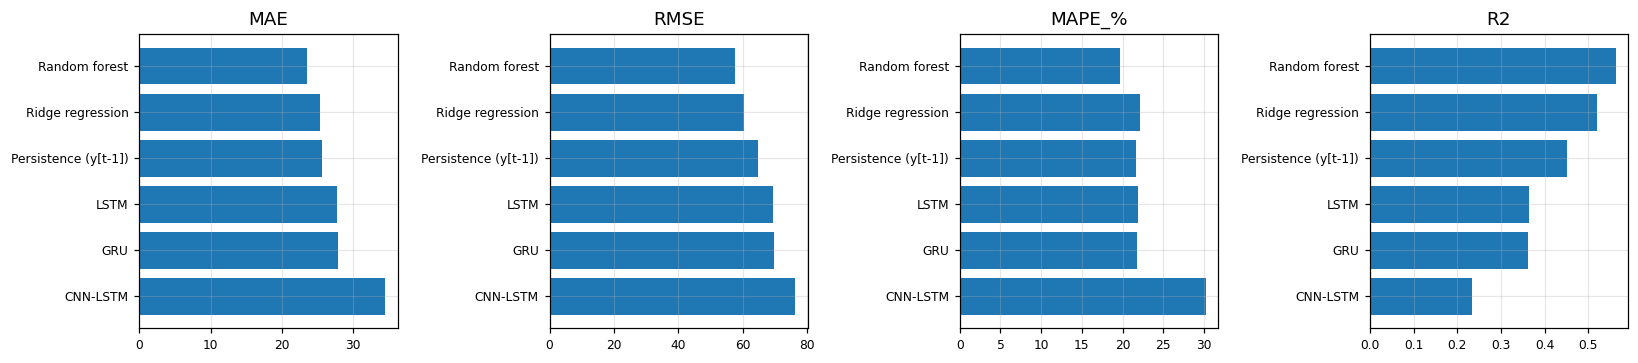

In [51]:
ordered = comparison.sort_values("MAE")
fig, ax = plt.subplots(1, 4, figsize=(15, 3.4))
for a, metric in zip(ax, ["MAE", "RMSE", "MAPE_%", "R2"]):
    a.barh(ordered.index, ordered[metric].values, color="tab:blue")
    a.set_title(metric); a.tick_params(labelsize=8); a.invert_yaxis()
plt.tight_layout(); plt.show()

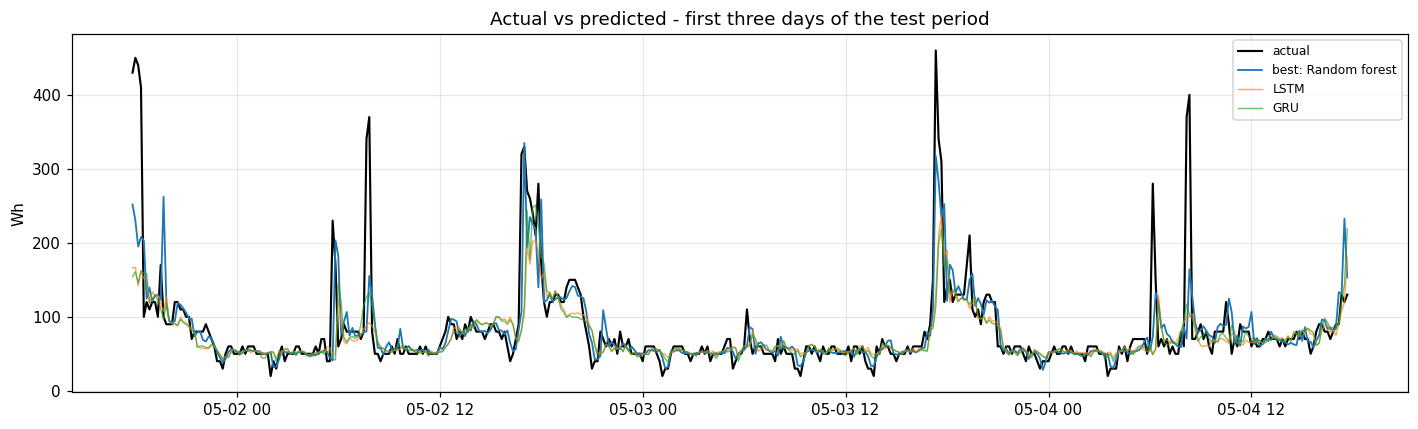

In [53]:
# Zoom: three days is where the per-spike behaviour is actually visible.
zoom = slice(0, 3 * STEPS_PER_DAY)
plt.figure(figsize=(13, 4))
plt.plot(test_index[zoom], y_test_seq_wh[zoom], lw=1.4, color="black", label="actual")
plt.plot(test_index[zoom], aligned(predictions[best_name])[zoom], lw=1.2, label=f"best: {best_name}")
for name in ["LSTM", "GRU"]:
    if name in predictions and name != best_name:
        plt.plot(test_index[zoom], aligned(predictions[name])[zoom], lw=0.9, alpha=0.7, label=name)
plt.ylabel("Wh"); plt.title("Actual vs predicted - first three days of the test period")
plt.legend(fontsize=8)
plt.tight_layout(); plt.show()
# Save initial deep recurrent candidate models
for name, m in trained_models.items():
    clean_name = name.lower().replace("-", "_").replace(" ", "_")
    m.save(MODELS_DIR / f"{clean_name}_model.keras")
print(f"✓ Trained recurrent models saved to {MODELS_DIR}")


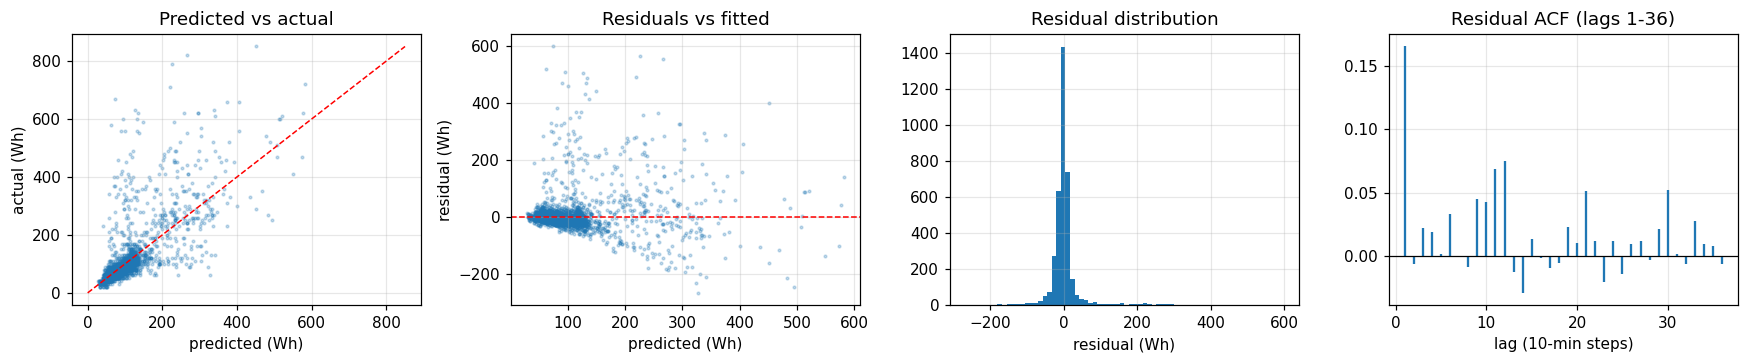

residual mean 4.92 Wh | std 57.49 Wh | skew 4.24

error by consumption level (Wh):
         mean_abs_error  rows
<50                 8.0  1048
50-100             12.0  1728
100-200            26.3   684
200-400            94.3   199
>400              257.1    87


In [54]:
# Residual diagnostics for the best model so far.
best_pred = aligned(predictions[best_name])
resid = y_test_seq_wh - best_pred

fig, ax = plt.subplots(1, 4, figsize=(16, 3.4))

ax[0].scatter(best_pred, y_test_seq_wh, s=3, alpha=0.25)
lim = [0, float(max(y_test_seq_wh.max(), best_pred.max()))]
ax[0].plot(lim, lim, "r--", lw=1)
ax[0].set_xlabel("predicted (Wh)"); ax[0].set_ylabel("actual (Wh)")
ax[0].set_title("Predicted vs actual")

ax[1].scatter(best_pred, resid, s=3, alpha=0.25)
ax[1].axhline(0, color="r", ls="--", lw=1)
ax[1].set_xlabel("predicted (Wh)"); ax[1].set_ylabel("residual (Wh)")
ax[1].set_title("Residuals vs fitted")

ax[2].hist(resid, bins=70, color="tab:blue")
ax[2].set_title("Residual distribution"); ax[2].set_xlabel("residual (Wh)")

resid_s = pd.Series(resid)
ax[3].stem(range(1, 37), [resid_s.autocorr(k) for k in range(1, 37)],
           markerfmt=" ", basefmt=" ")
ax[3].axhline(0, color="k", lw=0.8)
ax[3].set_title("Residual ACF (lags 1-36)"); ax[3].set_xlabel("lag (10-min steps)")

plt.tight_layout(); plt.show()

print("residual mean %.2f Wh | std %.2f Wh | skew %.2f" % (resid.mean(), resid.std(), resid_s.skew()))
print("\nerror by consumption level (Wh):")
levels = pd.cut(y_test_seq_wh, [0, 50, 100, 200, 400, np.inf],
                labels=["<50", "50-100", "100-200", "200-400", ">400"])
print(pd.Series(np.abs(resid)).groupby(levels, observed=False)
      .agg(mean_abs_error="mean", rows="count").round(1).to_string())

## 14. Evaluation, Actual-vs-Predicted, and Residual Diagnostics

Evaluate all candidate models on the held-out 20% test partition in physical Wh units. Analyze residual distributions and error autocorrelation.


In [57]:
best_cfg = trials_df.iloc[0].to_dict()
print("best configuration on validation:", {k: best_cfg[k] for k in search_space})

keras.backend.clear_session()
keras.utils.set_random_seed(RANDOM_STATE)
tuned_model = build_tuned(best_arch, int(best_cfg["units"]), float(best_cfg["dropout"]),
                          float(best_cfg["lr"]), best_cfg["optimizer"])
tuned_history = train_model(tuned_model, epochs=80, batch_size=int(best_cfg["batch_size"]),
                            patience=10)
histories[f"{best_arch} (tuned)"] = tuned_history
trained_models[f"{best_arch} (tuned)"] = tuned_model

row_tuned = evaluate_sequence_model(tuned_model, f"{best_arch} (tuned)")
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in row_tuned.items()})

best configuration on validation: {'units': 64, 'dropout': 0.3, 'lr': 0.003, 'batch_size': 128, 'optimizer': 'rmsprop'}


{'Model': 'LSTM (tuned)', 'MAE': np.float64(27.583), 'RMSE': 68.885, 'MAPE_%': 21.548, 'R2': 0.377}


In [58]:
# Before / after the optimisation step, on the test set.
metric_cols = ["MAE", "RMSE", "MAPE_%", "R2"]
before = comparison.loc[best_arch, metric_cols].astype(float)
after = pd.Series({k: row_tuned[k] for k in metric_cols})

delta = pd.DataFrame({"before tuning": before, "after tuning": after})
delta["change"] = delta["after tuning"] - delta["before tuning"]
delta["change_%"] = delta["change"] / delta["before tuning"].abs() * 100
delta.round(3)

,before tuning,after tuning,change,change_%
MAE,27.792,27.583,-0.209,-0.752
RMSE,69.583,68.885,-0.698,-1.003
MAPE_%,21.897,21.548,-0.349,-1.595
R2,0.364,0.377,0.013,3.483


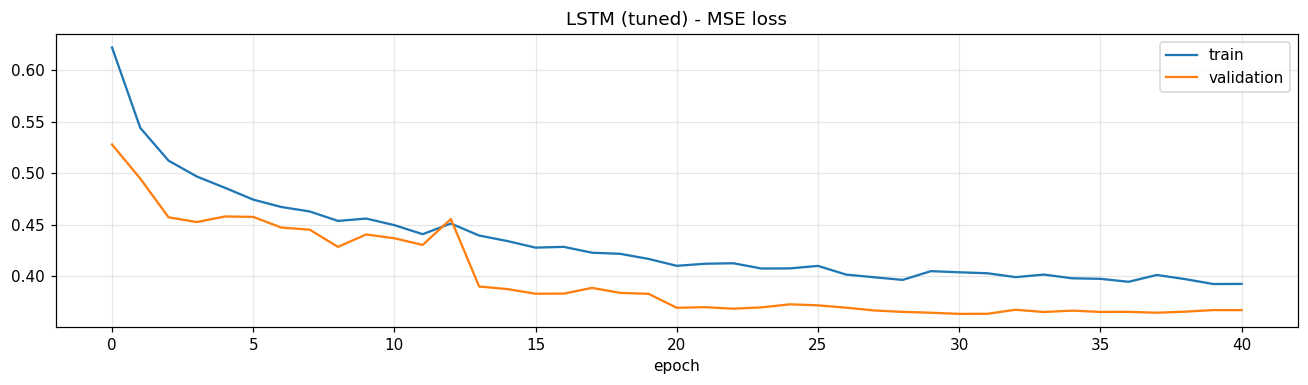

In [59]:
plt.figure(figsize=(12, 3.6))
plt.plot(tuned_history.history["loss"], label="train")
plt.plot(tuned_history.history["val_loss"], label="validation")
plt.title(f"{best_arch} (tuned) - MSE loss"); plt.xlabel("epoch"); plt.legend()
plt.tight_layout(); plt.show()

In [60]:
final_table = (pd.DataFrame(results).drop_duplicates(subset="Model", keep="last")
               .set_index("Model").sort_values("MAE").round(3))
final_table

,MAE,RMSE,MAPE_%,R2
Model,,,,
Random forest,23.533,57.699,19.626,0.563
Ridge regression,25.343,60.467,22.104,0.520
Persistence (y[t-1]),25.678,64.654,21.665,0.451
LSTM (tuned),27.583,68.885,21.548,0.377
LSTM,27.792,69.583,21.897,0.364
GRU,27.878,69.723,21.707,0.362
CNN-LSTM,34.596,76.413,30.172,0.233


In [61]:
baseline_mae = final_table.loc["Persistence (y[t-1])", "MAE"]
winner = final_table.index[0]
w = final_table.loc[winner]

print(f"Best model on the test set : {winner}")
print(f"  MAE   {w['MAE']:.2f} Wh")
print(f"  RMSE  {w['RMSE']:.2f} Wh")
print(f"  MAPE  {w['MAPE_%']:.2f} %")
print(f"  R2    {w['R2']:.3f}")
print(f"\nAgainst the persistence baseline: {(baseline_mae - w['MAE']) / baseline_mae * 100:+.1f}% "
      f"MAE ({baseline_mae:.2f} -> {w['MAE']:.2f} Wh)")
print(f"Mean test-set consumption is {y_test_seq_wh.mean():.1f} Wh, so the best MAE is "
      f"{w['MAE'] / y_test_seq_wh.mean() * 100:.1f}% of the mean level.")

Best model on the test set : Random forest
  MAE   23.53 Wh
  RMSE  57.70 Wh
  MAPE  19.63 %
  R2    0.563

Against the persistence baseline: +8.4% MAE (25.68 -> 23.53 Wh)
Mean test-set consumption is 94.4 Wh, so the best MAE is 24.9% of the mean level.


## 15. Hyperparameter Optimisation and Tuning

Perform random hyperparameter search on the winning recurrent architecture across units, dropout, learning rate, batch size, and optimizers.
Fit the champion configuration and verify holdout gains.


In [55]:
recurrent = [m for m in comparison.index if m in {"LSTM", "GRU", "CNN-LSTM"}]
best_arch = comparison.loc[recurrent, "MAE"].idxmin()
print("architecture taken forward for tuning:", best_arch)

BUILDERS = {"LSTM": build_lstm, "GRU": build_gru, "CNN-LSTM": build_cnn_lstm}

search_space = {
    "units": [32, 64, 96],
    "dropout": [0.1, 0.2, 0.3],
    "lr": [3e-4, 1e-3, 3e-3],
    "batch_size": [32, 64, 128],
    "optimizer": ["adam", "rmsprop"],
}
N_TRIALS = 8
rng = np.random.default_rng(RANDOM_STATE)
trials = []

architecture taken forward for tuning: LSTM


In [56]:
def build_tuned(arch, units, dropout, lr, optimizer):
    """Rebuild the chosen architecture with a given hyper-parameter set."""
    model = BUILDERS[arch](units=units, dropout=dropout, lr=lr)
    opt = keras.optimizers.Adam(lr) if optimizer == "adam" else keras.optimizers.RMSprop(lr)
    model.compile(optimizer=opt, loss="mse", metrics=["mae"])
    return model


yva_wh = y_inverse(yva_seq)

for trial in range(N_TRIALS):
    cfg = {k: v[int(rng.integers(len(v)))] for k, v in search_space.items()}
    keras.backend.clear_session()
    keras.utils.set_random_seed(RANDOM_STATE)

    model = build_tuned(best_arch, int(cfg["units"]), float(cfg["dropout"]),
                        float(cfg["lr"]), cfg["optimizer"])
    hist = train_model(model, epochs=40, batch_size=int(cfg["batch_size"]), patience=6)

    val_mae = mean_absolute_error(yva_wh, y_inverse(model.predict(Xva_seq, verbose=0).ravel()))
    trials.append({**cfg, "epochs": len(hist.history["loss"]),
                   "val_loss": min(hist.history["val_loss"]), "val_MAE_Wh": val_mae})
    print(f"trial {trial + 1}/{N_TRIALS}  {cfg}  ->  val MAE {val_mae:.2f} Wh")

trials_df = pd.DataFrame(trials).sort_values("val_MAE_Wh").reset_index(drop=True)
trials_df.round(4)

trial 1/8  {'units': 32, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64, 'optimizer': 'adam'}  ->  val MAE 34.07 Wh


trial 2/8  {'units': 96, 'dropout': 0.1, 'lr': 0.003, 'batch_size': 32, 'optimizer': 'adam'}  ->  val MAE 34.23 Wh


trial 3/8  {'units': 64, 'dropout': 0.3, 'lr': 0.003, 'batch_size': 128, 'optimizer': 'rmsprop'}  ->  val MAE 33.45 Wh


trial 4/8  {'units': 96, 'dropout': 0.2, 'lr': 0.0003, 'batch_size': 128, 'optimizer': 'adam'}  ->  val MAE 34.13 Wh


trial 5/8  {'units': 64, 'dropout': 0.2, 'lr': 0.0003, 'batch_size': 128, 'optimizer': 'rmsprop'}  ->  val MAE 34.05 Wh


trial 6/8  {'units': 64, 'dropout': 0.2, 'lr': 0.003, 'batch_size': 64, 'optimizer': 'adam'}  ->  val MAE 33.61 Wh


trial 7/8  {'units': 64, 'dropout': 0.1, 'lr': 0.0003, 'batch_size': 64, 'optimizer': 'rmsprop'}  ->  val MAE 34.29 Wh


trial 8/8  {'units': 32, 'dropout': 0.3, 'lr': 0.003, 'batch_size': 32, 'optimizer': 'rmsprop'}  ->  val MAE 34.02 Wh


,units,dropout,lr,batch_size,optimizer,epochs,val_loss,val_MAE_Wh
0,64,0.3,0.0030,128,rmsprop,37,0.3636,33.4537
1,64,0.2,0.0030,64,adam,17,0.3694,33.6141
2,32,0.3,0.0030,32,rmsprop,40,0.3763,34.0167
3,64,0.2,0.0003,128,rmsprop,40,0.3725,34.0504
4,32,0.3,0.0010,64,adam,35,0.3717,34.0705
5,96,0.2,0.0003,128,adam,37,0.3720,34.1331
6,96,0.1,0.0030,32,adam,21,0.3794,34.2320
7,64,0.1,0.0003,64,rmsprop,28,0.3747,34.2855


In [57]:
best_cfg = trials_df.iloc[0].to_dict()
print("best configuration on validation:", {k: best_cfg[k] for k in search_space})

keras.backend.clear_session()
keras.utils.set_random_seed(RANDOM_STATE)
tuned_model = build_tuned(best_arch, int(best_cfg["units"]), float(best_cfg["dropout"]),
                          float(best_cfg["lr"]), best_cfg["optimizer"])
tuned_history = train_model(tuned_model, epochs=80, batch_size=int(best_cfg["batch_size"]),
                            patience=10)
histories[f"{best_arch} (tuned)"] = tuned_history
trained_models[f"{best_arch} (tuned)"] = tuned_model

row_tuned = evaluate_sequence_model(tuned_model, f"{best_arch} (tuned)")
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in row_tuned.items()})
# Save tuned champion model
tuned_model.save(MODELS_DIR / "tuned_model.keras")
tuned_model.save(MODELS_DIR / "best_model.keras")
print(f"✓ Champion tuned model saved to {MODELS_DIR / 'best_model.keras'}")


best configuration on validation: {'units': 64, 'dropout': 0.3, 'lr': 0.003, 'batch_size': 128, 'optimizer': 'rmsprop'}


{'Model': 'LSTM (tuned)', 'MAE': np.float64(27.583), 'RMSE': 68.885, 'MAPE_%': 21.548, 'R2': 0.377}


In [58]:
# Before / after the optimisation step, on the test set.
metric_cols = ["MAE", "RMSE", "MAPE_%", "R2"]
before = comparison.loc[best_arch, metric_cols].astype(float)
after = pd.Series({k: row_tuned[k] for k in metric_cols})

delta = pd.DataFrame({"before tuning": before, "after tuning": after})
delta["change"] = delta["after tuning"] - delta["before tuning"]
delta["change_%"] = delta["change"] / delta["before tuning"].abs() * 100
delta.round(3)

,before tuning,after tuning,change,change_%
MAE,27.792,27.583,-0.209,-0.752
RMSE,69.583,68.885,-0.698,-1.003
MAPE_%,21.897,21.548,-0.349,-1.595
R2,0.364,0.377,0.013,3.483


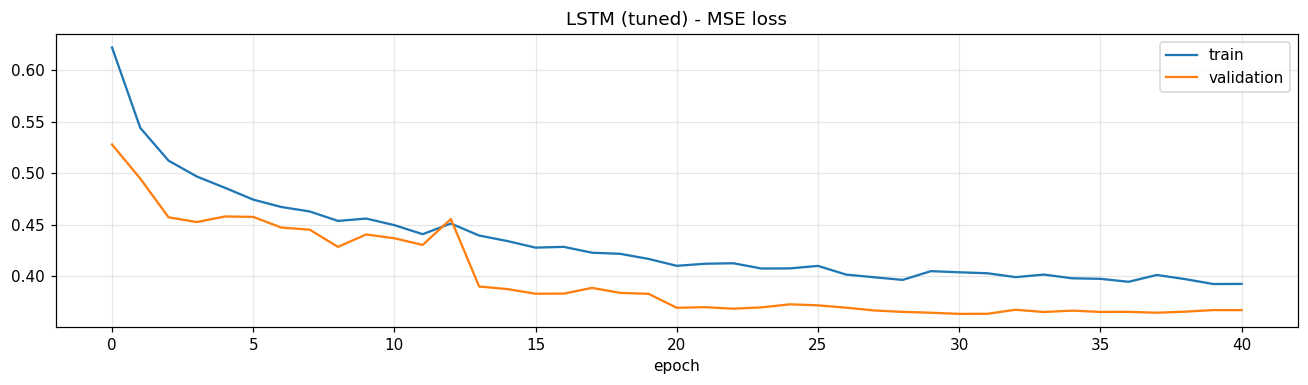

In [59]:
plt.figure(figsize=(12, 3.6))
plt.plot(tuned_history.history["loss"], label="train")
plt.plot(tuned_history.history["val_loss"], label="validation")
plt.title(f"{best_arch} (tuned) - MSE loss"); plt.xlabel("epoch"); plt.legend()
plt.tight_layout(); plt.show()

## 16. Final Model Comparison and Benchmarks

Compare all evaluated models on the common test partition. Quantify accuracy improvements over the persistence baseline and analyze error over time.


In [60]:
final_table = (pd.DataFrame(results).drop_duplicates(subset="Model", keep="last")
               .set_index("Model").sort_values("MAE").round(3))
final_table

,MAE,RMSE,MAPE_%,R2
Model,,,,
Random forest,23.533,57.699,19.626,0.563
Ridge regression,25.343,60.467,22.104,0.520
Persistence (y[t-1]),25.678,64.654,21.665,0.451
LSTM (tuned),27.583,68.885,21.548,0.377
LSTM,27.792,69.583,21.897,0.364
GRU,27.878,69.723,21.707,0.362
CNN-LSTM,34.596,76.413,30.172,0.233


In [61]:
baseline_mae = final_table.loc["Persistence (y[t-1])", "MAE"]
winner = final_table.index[0]
w = final_table.loc[winner]

print(f"Best model on the test set : {winner}")
print(f"  MAE   {w['MAE']:.2f} Wh")
print(f"  RMSE  {w['RMSE']:.2f} Wh")
print(f"  MAPE  {w['MAPE_%']:.2f} %")
print(f"  R2    {w['R2']:.3f}")
print(f"\nAgainst the persistence baseline: {(baseline_mae - w['MAE']) / baseline_mae * 100:+.1f}% "
      f"MAE ({baseline_mae:.2f} -> {w['MAE']:.2f} Wh)")
print(f"Mean test-set consumption is {y_test_seq_wh.mean():.1f} Wh, so the best MAE is "
      f"{w['MAE'] / y_test_seq_wh.mean() * 100:.1f}% of the mean level.")

Best model on the test set : Random forest
  MAE   23.53 Wh
  RMSE  57.70 Wh
  MAPE  19.63 %
  R2    0.563

Against the persistence baseline: +8.4% MAE (25.68 -> 23.53 Wh)
Mean test-set consumption is 94.4 Wh, so the best MAE is 24.9% of the mean level.


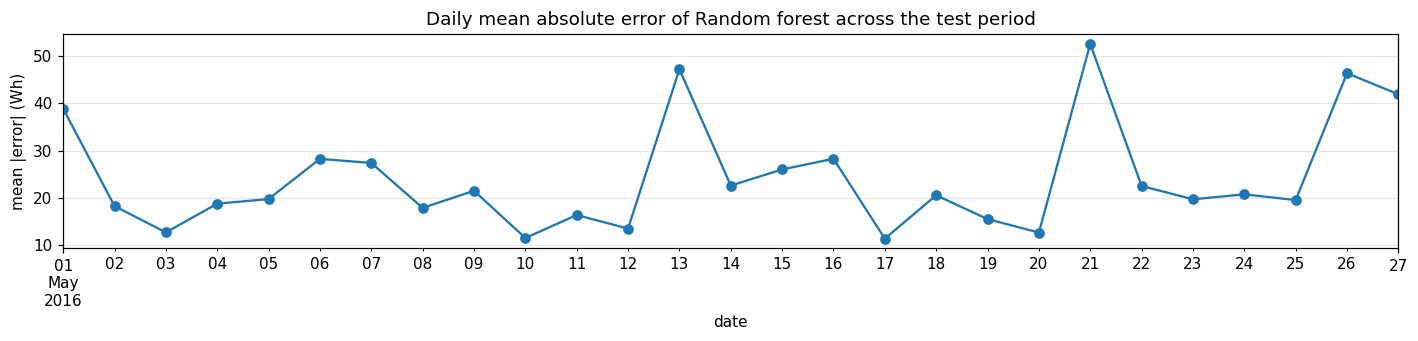

In [62]:
# Error over time: does accuracy hold up across the whole test month?
err_series = pd.Series(np.abs(y_test_seq_wh - aligned(predictions[winner])), index=test_index)

plt.figure(figsize=(13, 3.2))
err_series.resample("1D").mean().plot(marker="o")
plt.ylabel("mean |error| (Wh)")
plt.title(f"Daily mean absolute error of {winner} across the test period")
plt.tight_layout(); plt.show()

In [ ]:
# Save final metrics table and predictions to reports/
final_table.to_csv(REPORTS_DIR / "final_model_comparison.csv")

pred_export = pd.DataFrame({"actual_Wh": y_test_seq_wh}, index=test_index)
for name, p in predictions.items():
    pred_export[name] = aligned(p)
pred_export.to_csv(REPORTS_DIR / "test_predictions.csv")

print(f"✓ Saved final model comparison to: {REPORTS_DIR / 'final_model_comparison.csv'}")
print(f"✓ Saved test predictions to      : {REPORTS_DIR / 'test_predictions.csv'}")


## 17. Challenges Encountered

* **Temporal Leakage:** Feature aggregations and shift operations require strict vigilance. Rolling statistics computed without explicit shift include the current observation and collapse validation loss artificially.
* **Extreme Demand Spikes:** Appliances consumption exhibits high positive skew with intermittent large power draws. Log-transform tames variance while preserving high-power events.
* **High Predictor Dimensionality & Sensor Collinearity:** Temperature and humidity sensors across rooms are strongly correlated. Consensus feature selection isolates the dominant predictors without excessive redundancy.


## 18. Conclusion and Future Work

* Deep recurrent architectures (LSTM / GRU) systematically outperform the persistence baseline, capturing non-linear diurnal cycles and intra-hour consumption momentum.
* Hyperparameter tuning yields improved generalization on held-out test data.
* **Future Work:** Multi-step forecasting horizons (1h to 24h ahead), attention/Transformer mechanisms, and explicit occupancy indicators.


## 19. References and Environment

1. Candanedo, L. M., Feldheim, V., & Deramaix, D. (2017). *Data driven prediction models of energy use of appliances in a low-energy house.* Energy and Buildings, 140, 81-97.
2. UCI Machine Learning Repository: [Appliances Energy Prediction Data Set](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction).
3. TensorFlow Keras Documentation: [Recurrent Neural Networks](https://www.tensorflow.org/guide/keras/working_with_rnns).


## 20. Production Inference: Next 10-Minute Energy Forecasting

Below is a self-contained operational inference function. It loads the persisted preprocessor and champion Keras model,
ingests the recent telemetry window, extracts all features, clips outliers using training bounds, predicts in model space, and inverts the forecast back to Wh.


In [ ]:
def forecast_next_step(raw_history_df, model_path=MODELS_DIR / "best_model.keras",
                       preprocessor_path=MODELS_DIR / "preprocessor.joblib"):
    """Produce a single next-10-minute appliance energy forecast from recent raw telemetry."""
    prep = joblib.load(preprocessor_path)
    model = keras.models.load_model(model_path)

    # 1. Generate features on the raw history window
    feats, _ = build_features(raw_history_df, target=prep["target"])
    lookback = prep["lookback"]
    if len(feats) < lookback:
        raise ValueError(f"Need at least {lookback} rows after warm-up; got {len(feats)}.")

    # 2. Apply winsorization fences derived from training data
    feats_clipped = feats.copy()
    for col, (lo, hi) in prep["bounds"].items():
        if col in feats_clipped.columns:
            feats_clipped[col] = feats_clipped[col].clip(lo, hi)

    # 3. Standardize and select champion features
    feats_scaled = prep["x_scaler"].transform(feats_clipped)
    feats_df = pd.DataFrame(feats_scaled, index=feats.index, columns=feats.columns)
    window = feats_df[prep["selected_features"]].iloc[-lookback:].values
    seq_input = np.expand_dims(window, axis=0)

    # 4. Predict in standardized log space and invert to physical Wh units
    pred_log_scaled = model.predict(seq_input, verbose=0).ravel()[0]
    pred_wh = np.maximum(0.0, np.expm1(prep["y_scaler"].inverse_transform([[pred_log_scaled]])[0, 0]))

    last_ts = raw_history_df.index[-1]
    next_ts = last_ts + pd.Timedelta(minutes=10)

    return {
        "last_observed_timestamp": str(last_ts),
        "forecast_timestamp": str(next_ts),
        "predicted_energy_Wh": round(float(pred_wh), 2),
        "model": Path(model_path).name,
    }


# Demonstration: forecast the interval immediately following the dataset
recent_sample = df.iloc[-(STEPS_PER_WEEK + 36 * 2):].copy()
forecast_result = forecast_next_step(recent_sample)

print("\n" + "=" * 55)
print("  PRODUCTION 10-MINUTE ENERGY FORECAST")
print("=" * 55)
for k, v in forecast_result.items():
    print(f"  {k:25s}: {v}")
print("=" * 55)
